In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection 
from matplotlib.patches import Circle
from scipy.integrate import solve_ivp
import nolds as nd
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy.stats import pearsonr
import matplotlib.gridspec as gridspec
import pandas as pd

from matplotlib import rc

font = {'family' : 'serif',
    'serif': 'sans',
    'weight' : 'bold',
    'size'   : 10}

plt.rc('font', **font)
plt.rc('text', usetex=True)

Loaded time series from full_timeseries_theta_-5_tau_10.csv
Loaded metrics from metrics_results_theta_-5_tau_10.csv

Time series head:
           t        x1        y1     I1        x2        y2     I2
0  0.000000 -0.034805  0.100000  0.019  0.009810  0.100000  0.022
1  0.005465 -0.036482  0.099847  0.019  0.010615  0.099852  0.022
2  0.012283 -0.038637  0.099655  0.019  0.011652  0.099667  0.022
3  0.020599 -0.041364  0.099422  0.019  0.012967  0.099443  0.022
4  0.030261 -0.044672  0.099152  0.019  0.014568  0.099183  0.022

Extracted metrics:
K1       0.044013
K2       0.044066
se1      0.016368
se2      0.016369
ap1      0.361828
ap2      0.361835
we1      1.956818
we2      1.956814
h1       0.732540
h2       0.732523
ccMax    1.000000
ccMin   -0.395813
T12      0.000235
T21      0.000479
Name: 0, dtype: float64


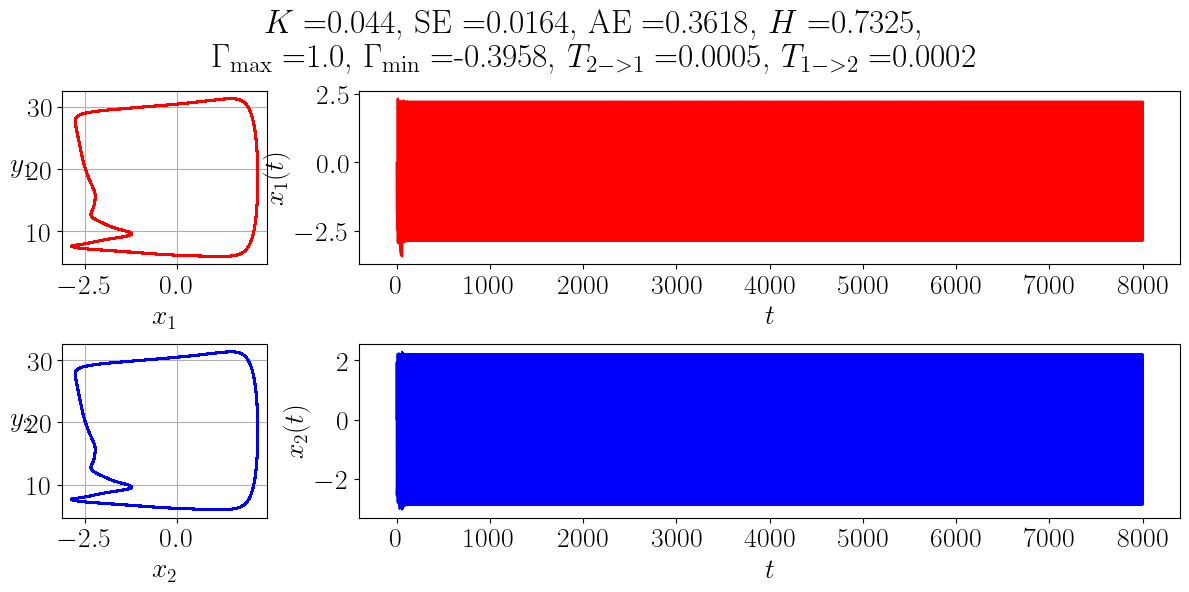

In [4]:
# specify the exact parameter values you used when saving
theta_val = -5
tau_val   = 10

# theta_val = -1
# tau_val   = 10

# theta_val = -0.1
# tau_val   = 10

# theta_val = -0.01
# tau_val   = 10

# theta_val = 0.01
# tau_val   = 10

# theta_val = 0.1
# tau_val   = 10

# theta_val = 1
# tau_val   = 10

# theta_val = 5
# tau_val   = 10

# theta_val = -5
# tau_val   = 40

# theta_val = -1
# tau_val   = 40

# theta_val = -0.1
# tau_val   = 40

# theta_val = -0.01
# tau_val   = 40

# theta_val = 0.01
# tau_val   = 40

# theta_val = 0.1
# tau_val   = 40

# theta_val = 1
# tau_val   = 40

# theta_val = 5
# tau_val   = 40

# theta_val = -5
# tau_val   = 70

# theta_val = -1
# tau_val   = 70

# theta_val = -0.1
# tau_val   = 70

# theta_val = -0.01
# tau_val   = 70

# theta_val = 0.01
# tau_val   = 70

# theta_val = 0.1
# tau_val   = 70

# theta_val = 1
# tau_val   = 70

# theta_val = 5
# tau_val   = 70

# theta_val = -5
# tau_val   = 100

# theta_val = -1
# tau_val   = 100

# theta_val = -0.1
# tau_val   = 100

# theta_val = -0.01
# tau_val   = 100

# theta_val = 0.01
# tau_val   = 100

# theta_val = 0.1
# tau_val   = 100

# theta_val = 1
# tau_val   = 100

# theta_val = 5
# tau_val   = 100




# construct the exact filenames
timeseries_filename = f"full_timeseries_theta_{theta_val}_tau_{tau_val}.csv"
metrics_filename    = f"metrics_results_theta_{theta_val}_tau_{tau_val}.csv"

# read the CSV files
df_ts = pd.read_csv(timeseries_filename)
df_metrics = pd.read_csv(metrics_filename)

print(f"Loaded time series from {timeseries_filename}")
print(f"Loaded metrics from {metrics_filename}")

# display the first few rows of each
print("\nTime series head:\n", df_ts.head(5))


# Extract the arrays if you want them
t  = df_ts["t"].values
x1 = df_ts["x1"].values
y1 = df_ts["y1"].values
I1 = df_ts["I1"].values

x2 = df_ts["x2"].values
y2 = df_ts["y2"].values
I2 = df_ts["I2"].values

# For metrics (single row)
metrics_row = df_metrics.iloc[0]  # only one row expected

K1  = metrics_row["K1"]
K2  = metrics_row["K2"]
se1 = metrics_row["se1"]
se2 = metrics_row["se2"]
ap1 = metrics_row["ap1"]
ap2 = metrics_row["ap2"]
we1 = metrics_row["we1"]
we2 = metrics_row["we2"]
h1  = metrics_row["h1"]
h2  = metrics_row["h2"]
ccMax = metrics_row["ccMax"]
ccMin = metrics_row["ccMin"]
T12 = metrics_row["T12"]
T21 = metrics_row["T21"]

print("\nExtracted metrics:")
print(metrics_row)


sz=20

fig, axs = plt.subplots(2, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 4]})
fig.tight_layout()
# plt.suptitle(
#     "$K=$" + str(round((K1 + K2) / 2, 4)) +
#     ", $\mathrm{SE}=$" + str(round((se1 + se2) / 2, 4)) +
#     ", $\mathrm{AE}=$" + str(round((ap1 + ap2) / 2, 4)) +
#     ", $\mathrm{WE}=$" + str(round((we1 + we2) / 2, 4)) +
#     ", $H=$" + str(round((h1 + h2) / 2, 4)) +
#     ", $RR=$" + str(round(RR, 4)) +
#     ", $DET=$" + str(round(DET, 4))+
#     ",\n $L=$" + str(round(L, 4)) +
#     ", $L_{\\rm max}=$" + str(round(Lmax, 4))+
#     ", $LAM=$" + str(round(LAM, 4)) +
#     ", $ENTR=$" + str(round(ENTR, 4)),
#     size=sz
# )
plt.suptitle(
    "$K=$" + str(round((K1 + K2) / 2, 4)) +
    ", $\mathrm{SE}=$" + str(round((se1 + se2) / 2, 4)) +
    ", $\mathrm{AE}=$" + str(round((ap1 + ap2) / 2, 4)) +
    # ", $\mathrm{WE}=$" + str(round((we1 + we2) / 2, 4)) +
    ", $H=$" + str(round((h1 + h2) / 2, 4)) +
    ",\n $\\Gamma_{\\rm max}=$" + str(round(ccMax, 4)) +
    ", $\\Gamma_{\\rm min}=$" + str(round(ccMin, 4)) +
    ", $T_{2 -> 1}=$" + str(round(T21, 4)) +
    ", $T_{1 -> 2}=$" + str(round(T12, 4)),
    size=sz+4
)
axs[0, 0].plot(x1[20000:], y1[20000:], 'r-', ms =1, rasterized=True)
# axs[0, 0].plot(phi_x1, phi_y1, 'bo', ms =5, rasterized=True)
axs[0, 0].set_xlabel('$x_1$', size=sz)
axs[0, 0].set_ylabel('$y_1$', rotation = False, size=sz)
axs[0, 0].tick_params(axis='both', labelsize=sz)
axs[0, 0].grid()

axs[1, 0].plot(x2[20000:], y2[20000:], 'b-', ms =1,  rasterized=True)
# axs[1, 0].plot(phi_x2, phi_y2, 'ro', ms =5,  rasterized=True)
axs[1, 0].set_xlabel('$x_2$', size=sz)
axs[1, 0].set_ylabel('$y_2$', rotation=False, size=sz)
axs[1, 0].tick_params(axis='both', labelsize=sz)
axs[1, 0].grid()

axs[0, 1].plot(t, x1, 'r-', ms=1, rasterized=True)
axs[0, 1].set_ylabel('$x_1(t)$', size=sz)
axs[0, 1].set_xlabel('$t$', size=sz)
axs[0, 1].tick_params(axis='both', labelsize=sz)

axs[1, 1].plot(t, x2, 'b-', ms=1, rasterized=True)
axs[1, 1].set_ylabel('$x_2(t)$', size=sz)
axs[1, 1].set_xlabel('$t$', size=sz)
axs[1, 1].tick_params(axis='both', labelsize=sz)

plt.tight_layout()

pdf_filename = f"figure_theta_{theta_val}_tau_{tau_val}.pdf"

plt.savefig(pdf_filename, bbox_inches='tight')

## Reading 2D plots

In [119]:
sz=22
def plot_metric_heatmap_with_contours(
    filename,
    title=None,
    cmap="viridis",
    vmin=None,
    vmax=None,
    n_contours=5,
    contour_color="white",
    contour_lw=0.6,
    figsize=(5, 5)
):

    # Load CSV
    df = pd.read_csv(filename)

    # Extract theta values
    theta = df["theta"].values

    # Extract tau values from column names
    tau = np.array([float(c) for c in df.columns[1:]])

    # Extract metric matrix
    Z = df.iloc[:, 1:].values

    # Create meshgrid
    Tau, Θ = np.meshgrid(tau, theta)

    plt.figure(figsize=figsize)

    # ---- Heatmap ----
    im = plt.pcolormesh(
        Tau, Θ, Z,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # ---- Contours ----
    cs = plt.contour(
        Tau, Θ, Z,
        levels=n_contours,
        colors=contour_color,
        linewidths=contour_lw
    )

    # plt.clabel(cs, inline=True, fontsize=9, fmt="%.2f")

    # ---- Colorbar ----
    # cbar = plt.colorbar(im)
    # cbar.ax.tick_params(labelsize=sz)
    # # cbar.set_label(title if title else "Metric value", size=sz)

    zmin = np.nanmin(Z)
    zmax = np.nanmax(Z)
    
    ticks = np.linspace(zmin, zmax, 6)
    
    cbar = plt.colorbar(im, ticks=ticks)
    cbar.ax.set_yticklabels([f"{t:.3f}" for t in ticks])
    cbar.ax.tick_params(labelsize=sz)

    # ---- Labels ----
    plt.xlabel("$\\tau$", size=sz)
    plt.ylabel("$\\theta$", size=sz, rotation=False)
    plt.xticks(fontsize=sz)
    plt.yticks(fontsize=sz)

    # if title is not None:
    #     plt.title(title, size=sz)

    plt.tight_layout()

    plt.savefig(filename.replace(".csv", ".pdf"), bbox_inches="tight")

    


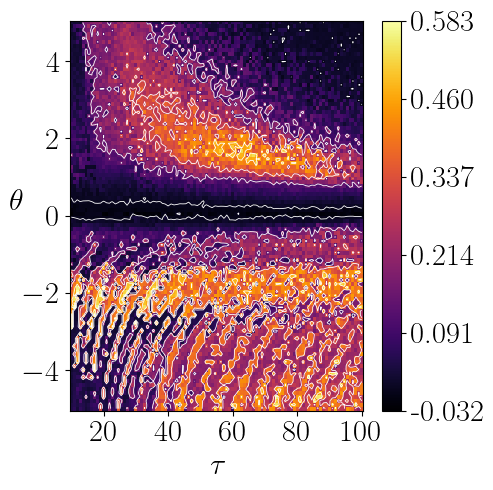

In [120]:
plot_metric_heatmap_with_contours(
    "KK.csv",
    cmap="inferno"
)

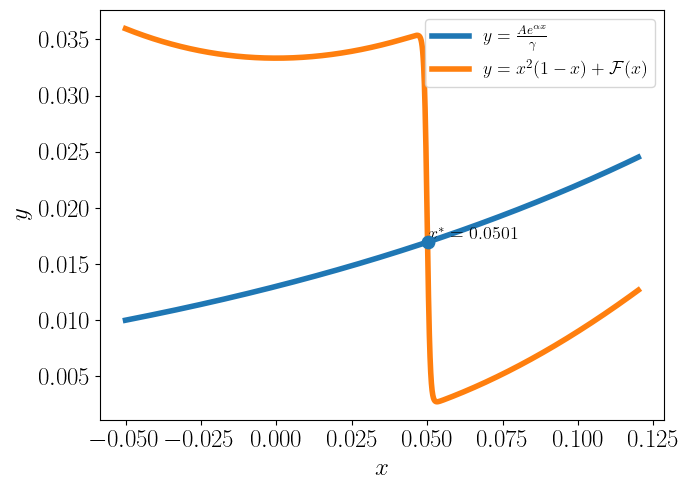

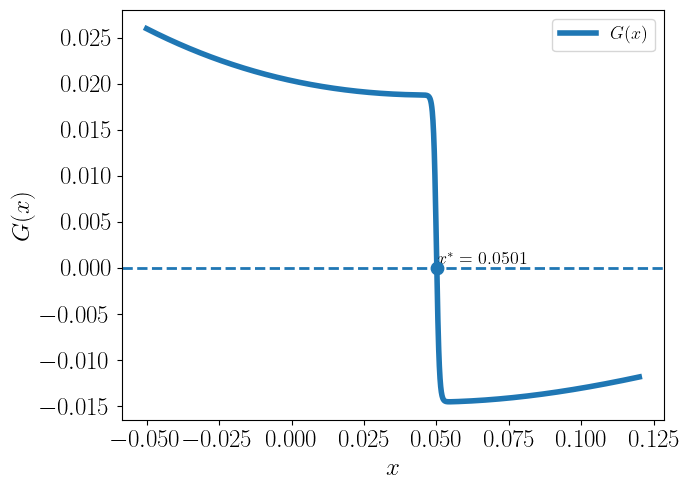

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.linalg import eigvals

# -----------------------------
# Parameters
# -----------------------------
A = 0.0041
alpha = 5.276
gamma = 0.315
eps = 0.0001

sz = 18

# -----------------------------
# Model functions
# -----------------------------
def F(x):
    return (1 / 60) * (1 + np.tanh((0.05 - x) / 0.001))

def Fprime(x):
    z = (0.05 - x) / 0.001
    return -(1 / (60 * 0.001)) * (1 / np.cosh(z))**2

def y_exp(x, A=A, alpha=alpha, gamma=gamma):
    return A * np.exp(alpha * x) / gamma

def y_cubic_adapt(x):
    return x**2 * (1 - x) + F(x)

def G(x, A=A, alpha=alpha, gamma=gamma):
    return x**2 * (1 - x) - A * np.exp(alpha * x) / gamma + F(x)

# -----------------------------
# Root finder for G(x)=0
# -----------------------------
def find_roots_1d(fun, xmin=-0.2, xmax=0.2, ngrid=50000):
    xs = np.linspace(xmin, xmax, ngrid)
    vals = fun(xs)

    roots = []

    for i in range(len(xs) - 1):
        if not np.isfinite(vals[i]) or not np.isfinite(vals[i + 1]):
            continue

        if vals[i] == 0:
            roots.append(xs[i])

        if vals[i] * vals[i + 1] < 0:
            try:
                r = brentq(fun, xs[i], xs[i + 1])
                if len(roots) == 0 or np.min(np.abs(np.array(roots) - r)) > 1e-6:
                    roots.append(r)
            except ValueError:
                pass

    return np.array(roots)


# ============================================================
# Figure 1A: Nullclines
# ============================================================
xgrid = np.linspace(-0.05, 0.12, 3000)

roots = find_roots_1d(lambda x: G(x, A, alpha, gamma), xmin=-0.2, xmax=0.2)

plt.figure(figsize=(7, 5))

plt.plot(
    xgrid,
    y_exp(xgrid, A, alpha, gamma),
    lw=4,
    label=r"$y=\frac{Ae^{\alpha x}}{\gamma}$"
)

plt.plot(
    xgrid,
    y_cubic_adapt(xgrid),
    lw=4,
    label=r"$y=x^2(1-x)+\mathcal{F}(x)$"
)

for r in roots:
    ystar = y_exp(r, A, alpha, gamma)
    plt.scatter(r, ystar, s=80, zorder=5)
    plt.text(r, ystar, rf"$x^*={r:.4f}$", fontsize=13, ha="left", va="bottom")

plt.xlabel(r"$x$", fontsize=sz)
plt.ylabel(r"$y$", fontsize=sz)
plt.xticks(fontsize=sz)
plt.yticks(fontsize=sz)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 1B: Equilibrium function G(x)
# ============================================================
plt.figure(figsize=(7, 5))

plt.plot(
    xgrid,
    G(xgrid, A, alpha, gamma),
    lw=4,
    label=r"$G(x)$"
)

plt.axhline(0, lw=2, ls="--")

for r in roots:
    plt.scatter(r, 0, s=80, zorder=5)
    plt.text(r, 0, rf"$x^*={r:.4f}$", fontsize=13, ha="left", va="bottom")

plt.xlabel(r"$x$", fontsize=sz)
plt.ylabel(r"$G(x)$", fontsize=sz)
plt.xticks(fontsize=sz)
plt.yticks(fontsize=sz)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 1C: Equilibrium branches as parameters vary
# ============================================================
def plot_equilibrium_branch(param_name, values, xlim=(-0.2, 0.2)):
    branch_param = []
    branch_x = []

    # LaTeX labels for x-axis
    latex_labels = {
        "A": r"$A$",
        "alpha": r"$\alpha$",
        "gamma": r"$\gamma$"
    }

    for val in values:
        A_tmp = A
        alpha_tmp = alpha
        gamma_tmp = gamma

        if param_name == "A":
            A_tmp = val
        elif param_name == "alpha":
            alpha_tmp = val
        elif param_name == "gamma":
            gamma_tmp = val
        else:
            raise ValueError("param_name must be 'A', 'alpha', or 'gamma'.")

        roots_tmp = find_roots_1d(
            lambda x: G(x, A_tmp, alpha_tmp, gamma_tmp),
            xmin=xlim[0],
            xmax=xlim[1]
        )

        for r in roots_tmp:
            branch_param.append(val)
            branch_x.append(r)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        branch_param,
        branch_x,
        s=25
    )

    plt.xlabel(latex_labels[param_name], fontsize=sz)
    plt.ylabel(r"$x^*$", fontsize=sz)

    plt.xticks(fontsize=sz)
    plt.yticks(fontsize=sz)

    plt.tight_layout()
    plt.show()


# Examples




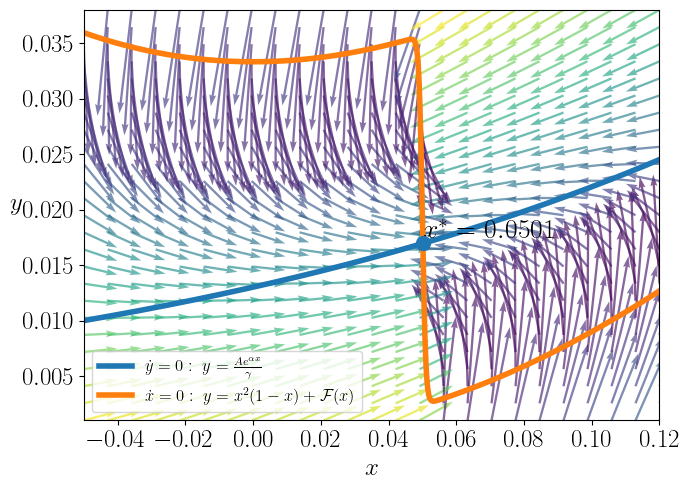

In [33]:
# ============================================================
# Figure 1A with quiver flow field
# Reduced x-y flow with I = F(x)
# ============================================================

def dx_reduced(x, y):
    return x**2 * (1 - x) - y + F(x)

def dy_reduced(x, y):
    return A * np.exp(alpha * x) - gamma * y


# Grid for vector field
x_min, x_max = -0.05, 0.12
y_min, y_max = 0.001, 0.038

xq = np.linspace(x_min, x_max, 25)
yq = np.linspace(y_min, y_max, 25)

X, Y = np.meshgrid(xq, yq)

U = dx_reduced(X, Y)
V = dy_reduced(X, Y)

# Normalize arrows so direction is visible
speed = np.sqrt(U**2 + V**2)
U_norm = U / (speed + 1e-12)
V_norm = V / (speed + 1e-12)


plt.figure(figsize=(7, 5))

# -----------------------------
# Quiver field
# -----------------------------
plt.quiver(
    X, Y,
    U_norm, V_norm,
    speed,
    angles="xy",
    scale_units="xy",
    scale=100,
    width=0.004,
    alpha=0.65
)

# -----------------------------
# Nullclines
# -----------------------------
plt.plot(
    xgrid,
    y_exp(xgrid, A, alpha, gamma),
    lw=4,
    label=r"$\dot y=0:\ y=\frac{Ae^{\alpha x}}{\gamma}$"
)

plt.plot(
    xgrid,
    y_cubic_adapt(xgrid),
    lw=4,
    label=r"$\dot x=0:\ y=x^2(1-x)+\mathcal{F}(x)$"
)

# -----------------------------
# Equilibria
# -----------------------------
for r in roots:
    ystar = y_exp(r, A, alpha, gamma)
    plt.scatter(r, ystar, s=100, zorder=5)
    plt.text(
        r,
        ystar,
        rf"$x^*={r:.4f}$",
        fontsize=20,
        ha="left",
        va="bottom"
    )

plt.xlabel(r"$x$", fontsize=sz)
plt.ylabel(r"$y$", fontsize=sz, rotation=0)

plt.xticks(fontsize=sz)
plt.yticks(fontsize=sz)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("reducedxy.pdf", bbox_inches="tight")

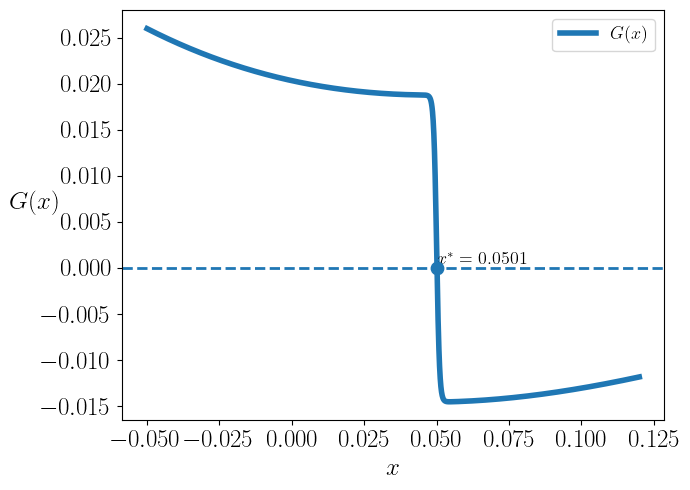

In [35]:
# ============================================================
# Figure 1B: Equilibrium function G(x)
# ============================================================
plt.figure(figsize=(7, 5))

plt.plot(
    xgrid,
    G(xgrid, A, alpha, gamma),
    lw=4,
    label=r"$G(x)$"
)

plt.axhline(0, lw=2, ls="--")

for r in roots:
    plt.scatter(r, 0, s=80, zorder=5)
    plt.text(r, 0, rf"$x^*={r:.4f}$", fontsize=13, ha="left", va="bottom")

plt.xlabel(r"$x$", fontsize=sz)
plt.ylabel(r"$G(x)$", fontsize=sz, rotation=False)
plt.xticks(fontsize=sz)
plt.yticks(fontsize=sz)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig("G.pdf", bbox_inches="tight")